1. Import Library

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
import joblib

2. Load Data

In [ ]:
#load data dan menampilkan 5 baris data teratas
df = pd.read_csv("")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Total charges seharusnya type datanya float tetapi di info type datanya malah object berarti ada data "..." atau kosong di kolom total charges nya

- customerID - nilai unik yang mengidentifikasi pelanggan 
- gender - apakah pelanggan laki-laki atau perempuan 
- SeniorCitizen - apakah pelanggan seorang lansia atau tidak (1, 0) 
- Partner - apakah pelanggan memiliki pasangan atau tidak (Ya, Tidak) 
- Dependents - apakah pelanggan memiliki tanggungan atau tidak (Ya, Tidak). 
- Tanggungan adalah seseorang yang bergantung pada orang lain sebagai sumber utama penghasilan, tenure - jumlah bulan pelanggan telah tinggal di perusahaan 
- PhoneService - apakah pelanggan memiliki layanan telepon atau tidak (Ya, Tidak) 
- MultipleLines - apakah pelanggan memiliki beberapa saluran atau tidak (Ya, Tidak, Tidak ada layanan telepon) 
- InternetService - penyedia layanan internet pelanggan (DSL, Fiber optic, Tidak) 
- OnlineSecurity - apakah pelanggan memiliki keamanan online atau tidak (Ya, Tidak, Tidak ada layanan internet) 
- OnlineBackup - apakah pelanggan memiliki cadangan online atau tidak (Ya, Tidak, Tidak ada layanan internet) 
- DeviceProtection - apakah pelanggan memiliki perlindungan perangkat atau tidak (Ya, Tidak, Tidak ada layanan internet)
- TechSupport - apakah pelanggan memiliki dukungan teknis atau tidak (Ya, Tidak, Tidak ada layanan internet)
- StreamingTV - apakah pelanggan memiliki TV streaming atau tidak (Ya, Tidak, Tidak ada layanan internet)
- StreamingMovies - apakah pelanggan memiliki film streaming atau tidak (Ya, Tidak, Tidak ada layanan internet)
- Contract - jenis kontrak menurut durasi (Bulan ke bulan, Satu tahun, Dua tahun)
- PaperlessBilling - tagihan yang diterbitkan dalam bentuk tanpa kertas (Ya, Tidak)
- PaymentMethod - metode pembayaran yang digunakan oleh pelanggan (Cek elektronik, Cek melalui pos, Kartu kredit (otomatis), - Transfer bank (otomatis))
- MonthlyCharges - jumlah biaya untuk layanan setiap bulan
- TotalCharges - jumlah biaya kumulatif untuk layanan selama masa berlangganan (tenure)
- Churn – nilai output, variabel prediksi

In [5]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# Mengecek dataset menggunakan isnull().sum()
df.duplicated().sum()

np.int64(0)

In [7]:
# Mengecek dataset menggunakan duplicated().sum()
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

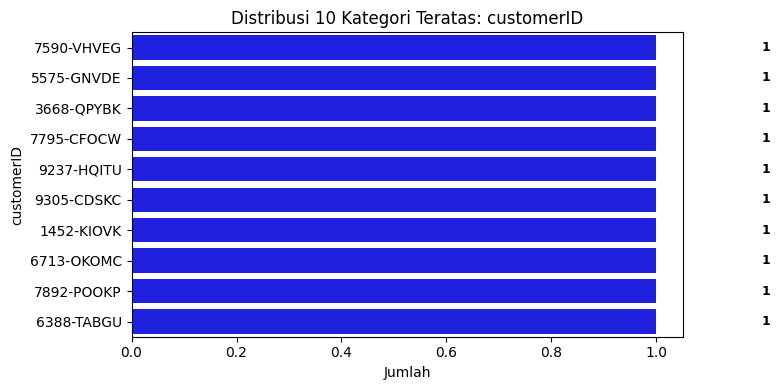

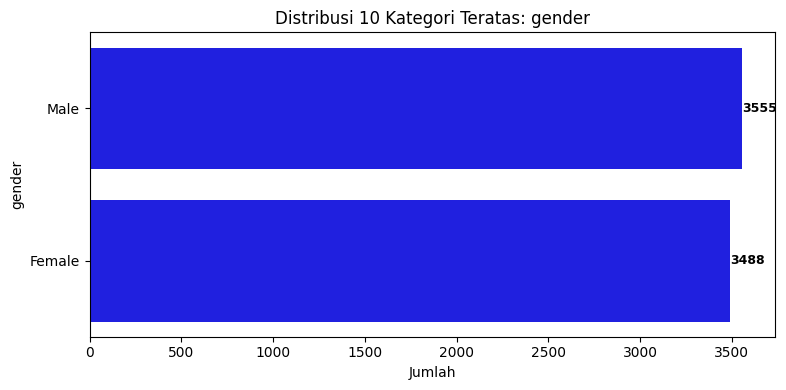

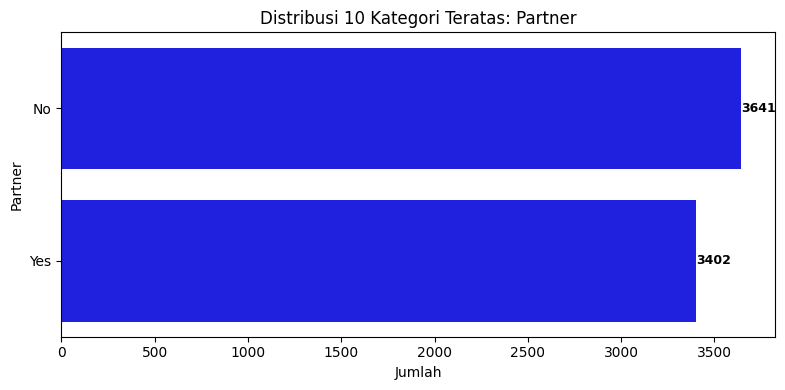

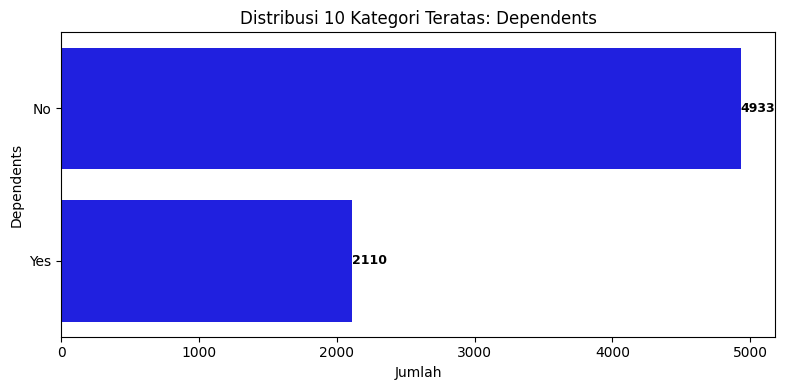

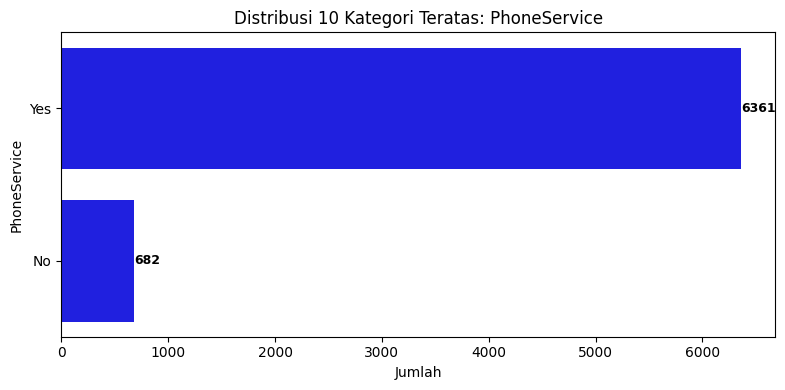

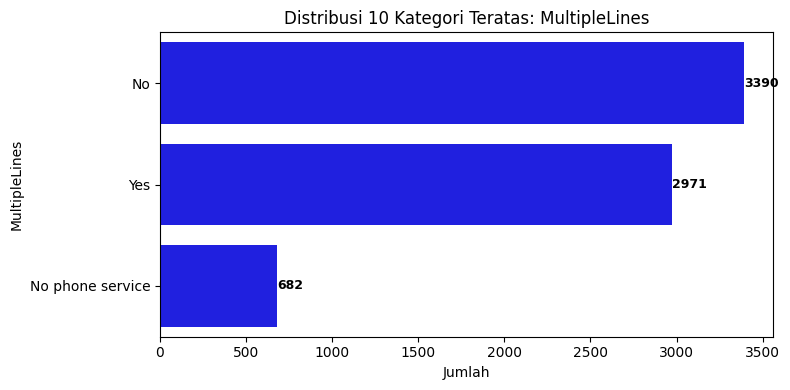

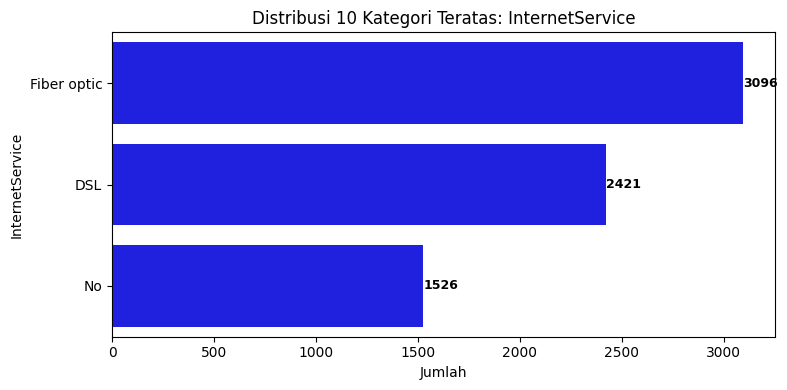

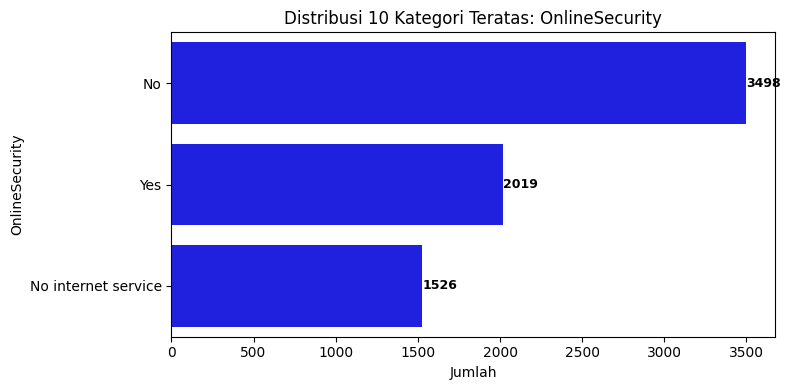

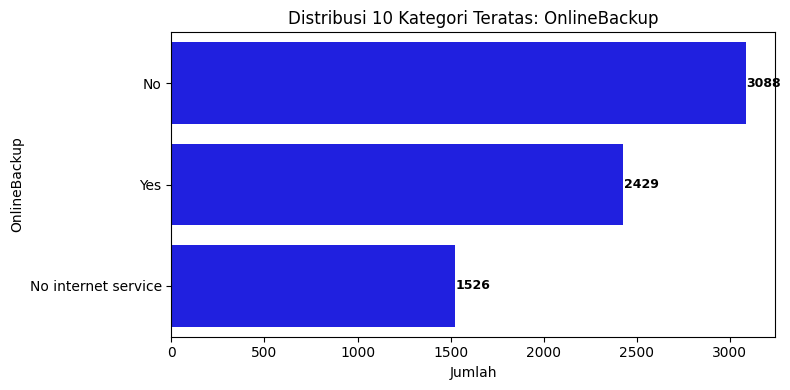

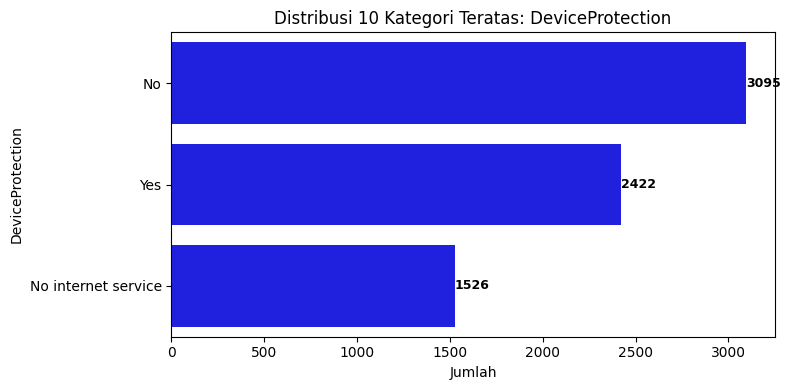

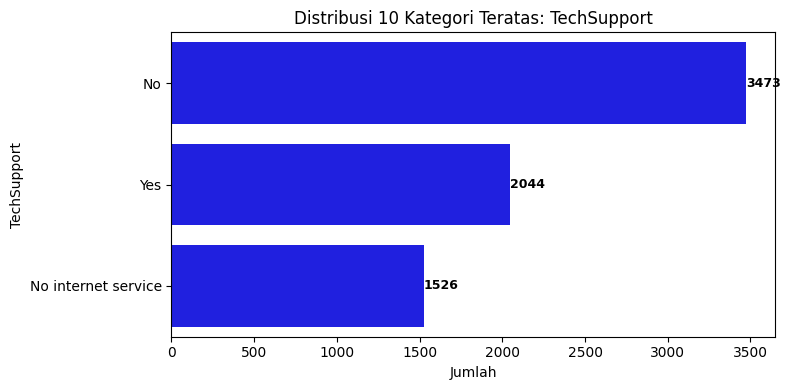

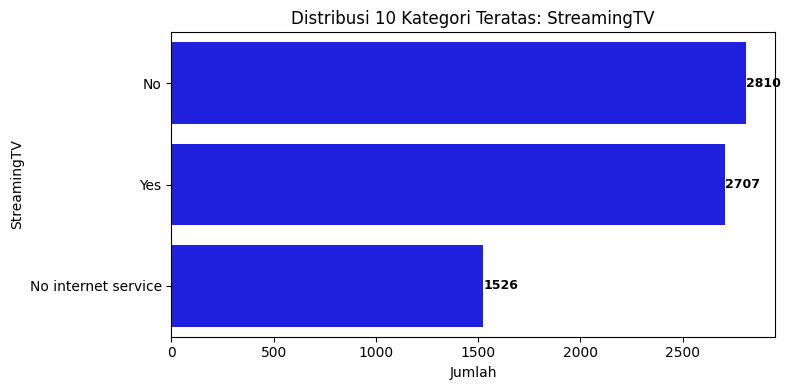

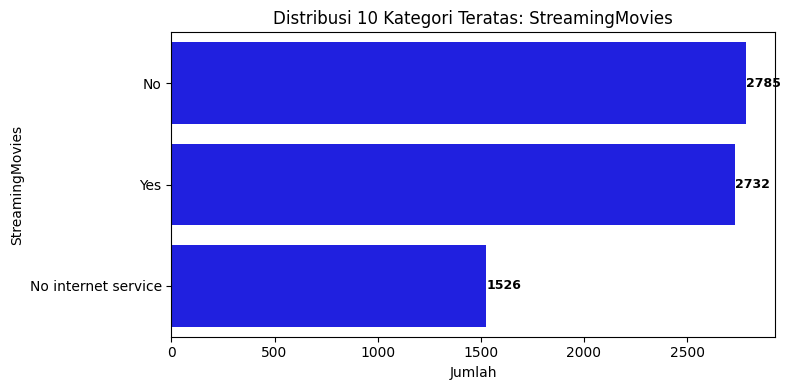

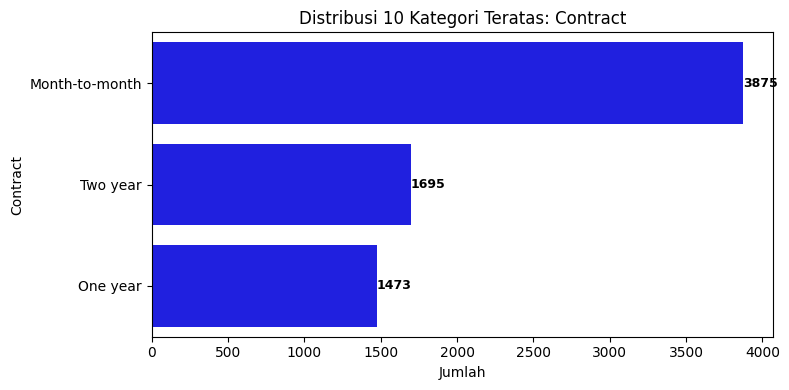

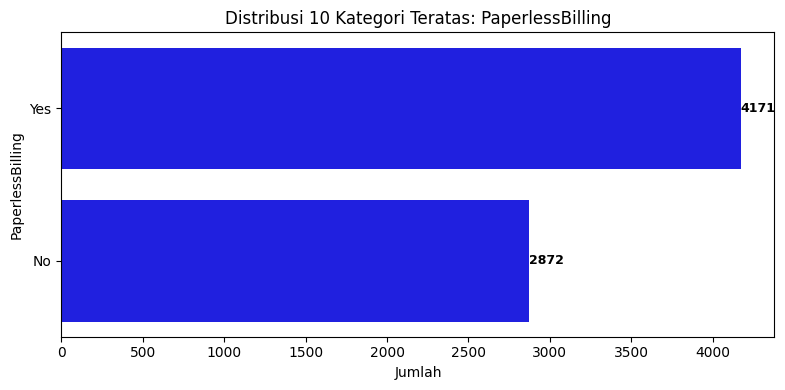

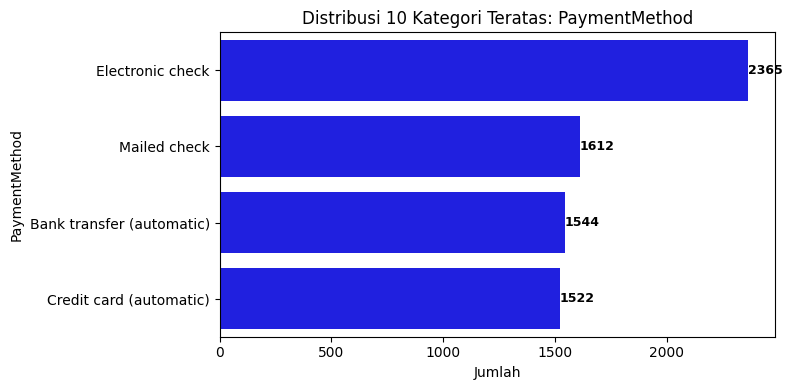

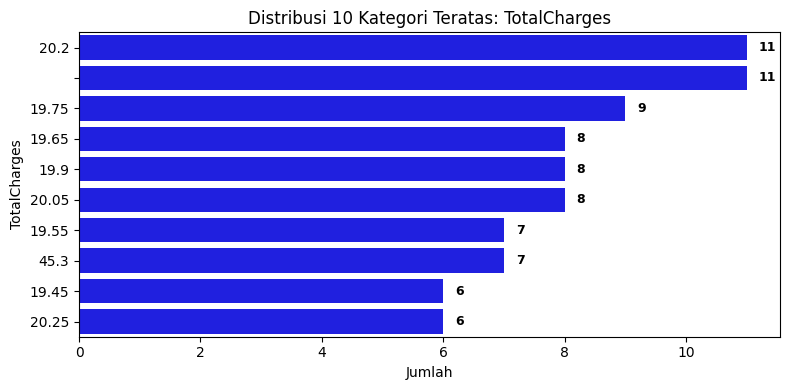

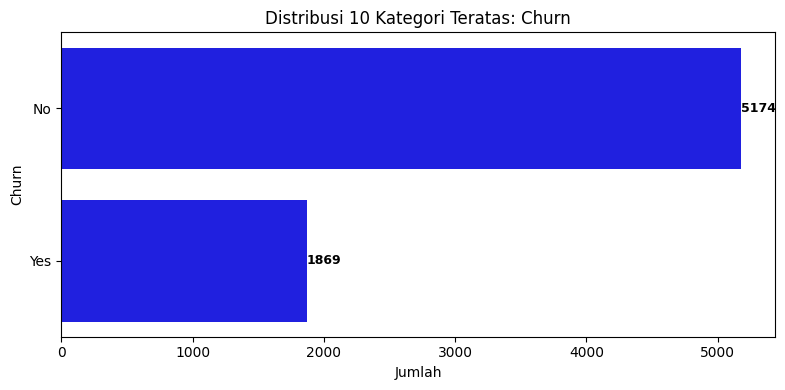

In [8]:
kategorikal = df.select_dtypes(include=[object])

for col in kategorikal:
    plt.figure(figsize=(8,4))
    
    # Ambil 10 kategori paling sering muncul
    top10 = df[col].value_counts().head(10)
    
    sns.barplot(
        x=top10.values, 
        y=top10.index, 
        color='blue'
    )
    
    #angka di ujung bar
    for i, v in enumerate(top10.values):
        plt.text(v + 0.2, i, str(v), va='center', fontsize=9, fontweight="bold")
    
    plt.title(f"Distribusi 10 Kategori Teratas: {col}")
    plt.xlabel("Jumlah")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

3. Preprocessing

In [ ]:
#mengecek kolom total charges yang datanya "..."
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
#mengubah data "..." pada kolom total charges menjadi NaN
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"], errors="coerce"
)
#menghapus data yang kosong 
df.dropna(inplace=True)


In [ ]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [15]:
#menghapus kolom customerID karena tidak diperlukan untuk melatih model
df.drop("customerID", axis=1, inplace=True)

In [16]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal
kategorikal = df.select_dtypes(include=[object])
encoders = {}  
for col in kategorikal:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

print("Hasil Encoding dengan LabelEncoder:")
df.head()

Hasil Encoding dengan LabelEncoder:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


4. Split Data

In [18]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

5. Modelling

In [ ]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": [None, "sqrt", "log2"],
    "splitter": ["best", "random"]
}

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

In [ ]:
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [ ]:
grid.fit(X_train, y_train)

In [ ]:
print("Best Parameters:")
print(grid.best_params_)

In [ ]:
best_model = grid.best_estimator_

6. Evaluasi

In [ ]:
# Menampilkan hasil evaluasi akurasi, presisi, recall, dan F1-Score pada seluruh algoritma yang sudah dibuat.
#decision tree
y_pred = clf.predict(X_test)
print("Hasil Evaluasi Decision Tree")
# Akurasi
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nHasil Klasifikasi:")
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix dalam bentuk array
cm = confusion_matrix(y_test, y_pred)

# Menampilkan dalam bentuk tabel biasa
print("\nConfusion Matrix:")
print(cm)

# Menampilkan visual dengan seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Positif'],
            yticklabels=['Negatif', 'Positif'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

7. Simpan Model

In [ ]:
joblib.dump((model, X.columns), "model.pkl")

print("Model saved!")